In [3]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler


## Standardization

In [7]:
ss= StandardScaler()
ss.fit(df[['SalePrice']])
df1= ss.transform(df[['SalePrice']])
df1= pd.DataFrame(df1, columns=['SalePrice'])
df1.head()

,SalePrice
0,0.428229
1,-0.948957
2,-0.110125
3,0.791305
4,0.113980


In [8]:
df['SalePrice'].isnull().sum()  

np.int64(0)

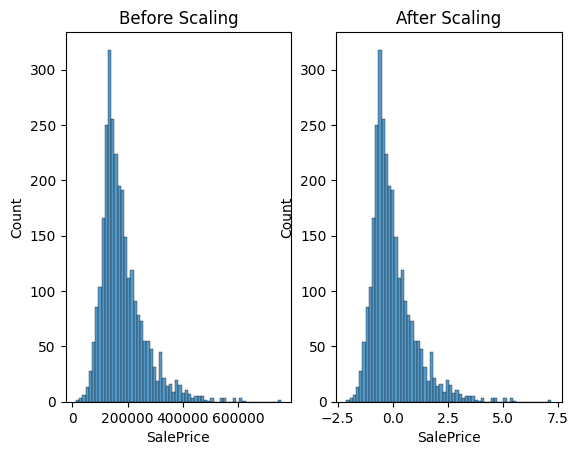

In [12]:
plt.subplot(1,2,1)
plt.title('Before Scaling')
sns.histplot(df['SalePrice'])
plt.subplot(1,2,2)
plt.title('After Scaling')
sns.histplot(df1['SalePrice'])
plt.show()

## Normalization

In [3]:
from sklearn.preprocessing import MinMaxScaler
mms= MinMaxScaler()
mms.fit(df[['SalePrice']])


,feature_range,"(0, ...)"
,copy,True
,clip,False


In [4]:
df2= mms.transform(df[['SalePrice']])
df2= pd.DataFrame(df2, columns=['SalePrice'])
df2.head()

,SalePrice
0,0.272444
1,0.124238
2,0.214509
3,0.311517
4,0.238626


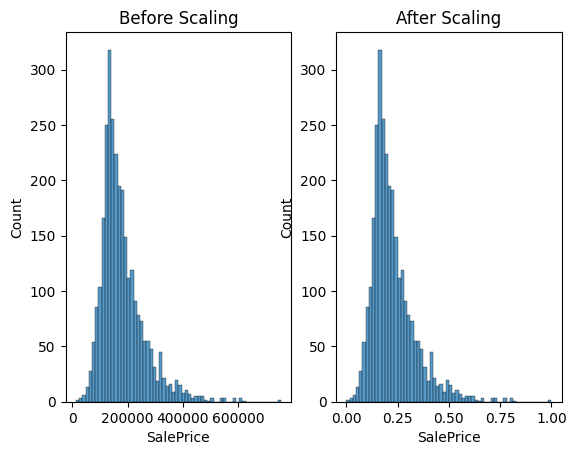

In [5]:
plt.subplot(1,2,1)
plt.title('Before Scaling')
sns.histplot(df['SalePrice'])
plt.subplot(1,2,2)
plt.title('After Scaling')
sns.histplot(df2['SalePrice'])
plt.show()

## Duplicate Data

In [6]:
df.duplicated().sum()

np.int64(0)

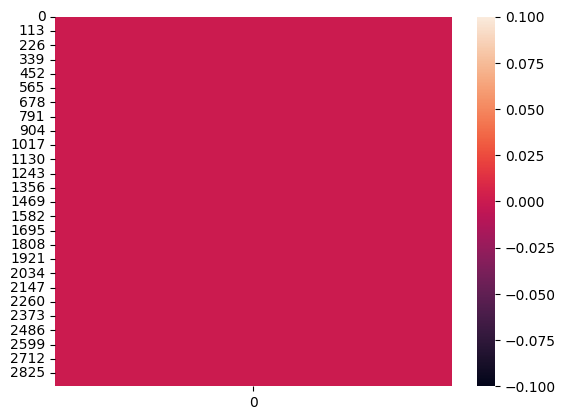

In [9]:
sns.heatmap(df.duplicated().astype(int).values.reshape(-1, 1))
plt.show()

In [10]:
df.drop_duplicates(inplace=True)

## Replacing and changing Data type

In [38]:
df= pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype        
---  ------           --------------  -----        
 0   Order            2930 non-null   int64        
 1   PID              2930 non-null   int64        
 2   MS SubClass      2930 non-null   int64        
 3   MS Zoning        2930 non-null   object       
 4   Lot Frontage     2440 non-null   float64      
 5   Lot Area         2930 non-null   int64        
 6   Street           2930 non-null   object       
 7   Alley            198 non-null    object       
 8   Lot Shape        2930 non-null   object       
 9   Land Contour     2930 non-null   object       
 10  Utilities        2930 non-null   object       
 11  Lot Config       2930 non-null   object       
 12  Land Slope       2930 non-null   object       
 13  Neighborhood     2930 non-null   object       
 14  Condition 1      2930 non-null   object       
 15  Cond

In [47]:
df.replace('Grvl', 'Gravel', inplace=True)

In [48]:
df['Yr Sold'] = df['Yr Sold'].astype('datetime64[Y]')

## Practice Data Cleaning

In [4]:
dt= pd.read_csv('Ticket.csv')
dt.head()

,Customer_ID,Date,Name,Email,Product_Category,Issue_Description,Priority,Resolution_Time,Rating,Resolved
0,1001,2024-01-15,John Smith,john.smith@email.com,Electronics,Product won't turn on,High,2.5,4.0,Yes
1,1002,2024-01-15,Jane Doe,jane.d@email.com,Books,Missing pages,Medium,1.0,5.0,Yes
2,1003,2024-01-16,Robert Johnson,robert.j@email.com,Electronics,"Battery drains quickly, battery issue",High,4.0,3.0,Yes
3,1004,2024-01-16,Alice Brown,alice.brown@email.com,Clothing,Size too small,Low,0.5,NaN,No
4,1005,2024-01-17,NaN,david.w@email.com,Electronics,"Screen cracked, broken display",High,72.0,2.0,Yes


In [5]:
dt.shape

(15, 10)

In [56]:
dt.isnull().sum()

Customer_ID          0
Date                 0
Name                 0
Email                0
Product_Category     0
Issue_Description    0
Priority             0
Resolution_Time      0
Rating               0
Resolved             0
dtype: int64

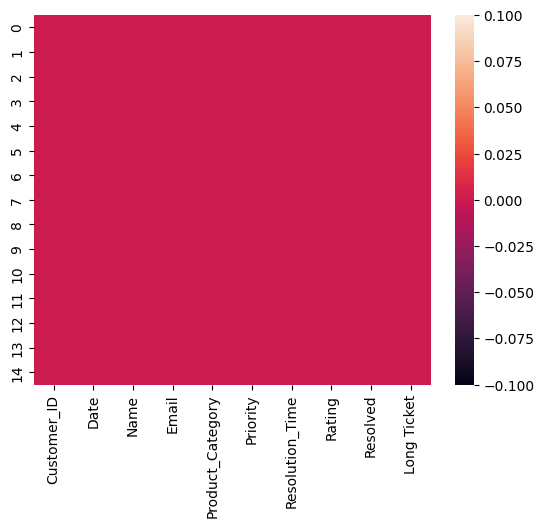

In [19]:
sns.heatmap(dt.isnull())
plt.show()

In [18]:
dt.iloc[12,2] = 'Mike B'

In [7]:
dt['Product_Category'].fillna(dt['Product_Category'].mode()[0], inplace=True)

C:\Users\Mazhar Iqbal\AppData\Local\Temp\ipykernel_10912\255716959.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dt['Product_Category'].fillna(dt['Product_Category'].mode()[0], inplace=True)


In [8]:
dt['Resolved']= dt['Resolved'].fillna('No')

In [9]:
dt['Resolution_Time']= dt['Resolution_Time'].fillna(26)

In [10]:
dt['Rating']= dt['Rating'].fillna(0)

In [67]:
dt.dtypes

Customer_ID                   int64
Date                 datetime64[ns]
Name                         object
Email                        object
Product_Category             object
Issue_Description            object
Priority                     object
Resolution_Time             float64
Rating                      float64
Resolved                     object
dtype: object

In [13]:
pd.to_datetime(dt['Date'])
dt['Date'].dtype

dtype('O')

In [12]:
dt.iloc[13,1] = '2024-01-21'

In [68]:
dt.duplicated().sum()

np.int64(0)

In [14]:
dt.drop(columns=['Issue_Description'], inplace=True)

In [36]:
dt

,Customer_ID,Date,Name,Email,Product_Category,Priority,Resolution_Time,Rating,Resolved,Long Ticket
0,1001,2024-01-15,John Smith,john.smith@email.com,Electronics,3,2.5,4.0,Yes,0
1,1002,2024-01-15,Jane Doe,jane.d@email.com,Books,2,1.0,5.0,Yes,0
2,1003,2024-01-16,Robert Johnson,robert.j@email.com,Electronics,3,4.0,3.0,Yes,0
3,1004,2024-01-16,Alice Brown,alice.brown@email.com,Clothing,1,0.5,0.0,No,0
4,1005,2024-01-17,David W,david.w@email.com,Electronics,3,72.0,2.0,Yes,1
5,1006,2024-01-17,Sarah Wilson,sarah.w@email.com,Home,1,24.0,0.0,No,0
6,1007,2024-01-18,John Smith,john.smith@email.com,Electronics,4,26.0,1.0,No,0
7,1008,2024-01-18,Maria Garcia,maria.g@email.com,Books,2,3.0,4.0,Yes,0
8,1009,2024-01-19,Tom Chen,tom.c@email.com,Electronics,3,48.0,0.0,No,1
9,1010,2024-01-19,Emily White,emily.white@email.com,Electronics,2,6.0,3.0,Yes,0


In [71]:
dt['Priority'].value_counts()

Priority
High      5
Medium    4
Low       3
Urgent    3
Name: count, dtype: int64

In [16]:
dt['Priority'] = dt['Priority'].map({'High': 3, 'Medium': 2, 'Low': 1, 'Urgent': 4})

In [34]:
dt['Long Ticket'] = dt['Resolution_Time'] >= 48

In [35]:
dt['Long Ticket'] = dt['Long Ticket'].map({True: 1, False: 0})

In [37]:
dt.to_csv('Ticket Cleaned.csv', index=False)